### Step 1: Load the Libraies and Data

In [371]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score , mean_absolute_percentage_error, root_mean_squared_error
from keras.layers import LSTM, Dense, Dropout, GRU, Conv1D, SimpleRNN
from keras.callbacks import EarlyStopping 

In [372]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_30088\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [373]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [374]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [375]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

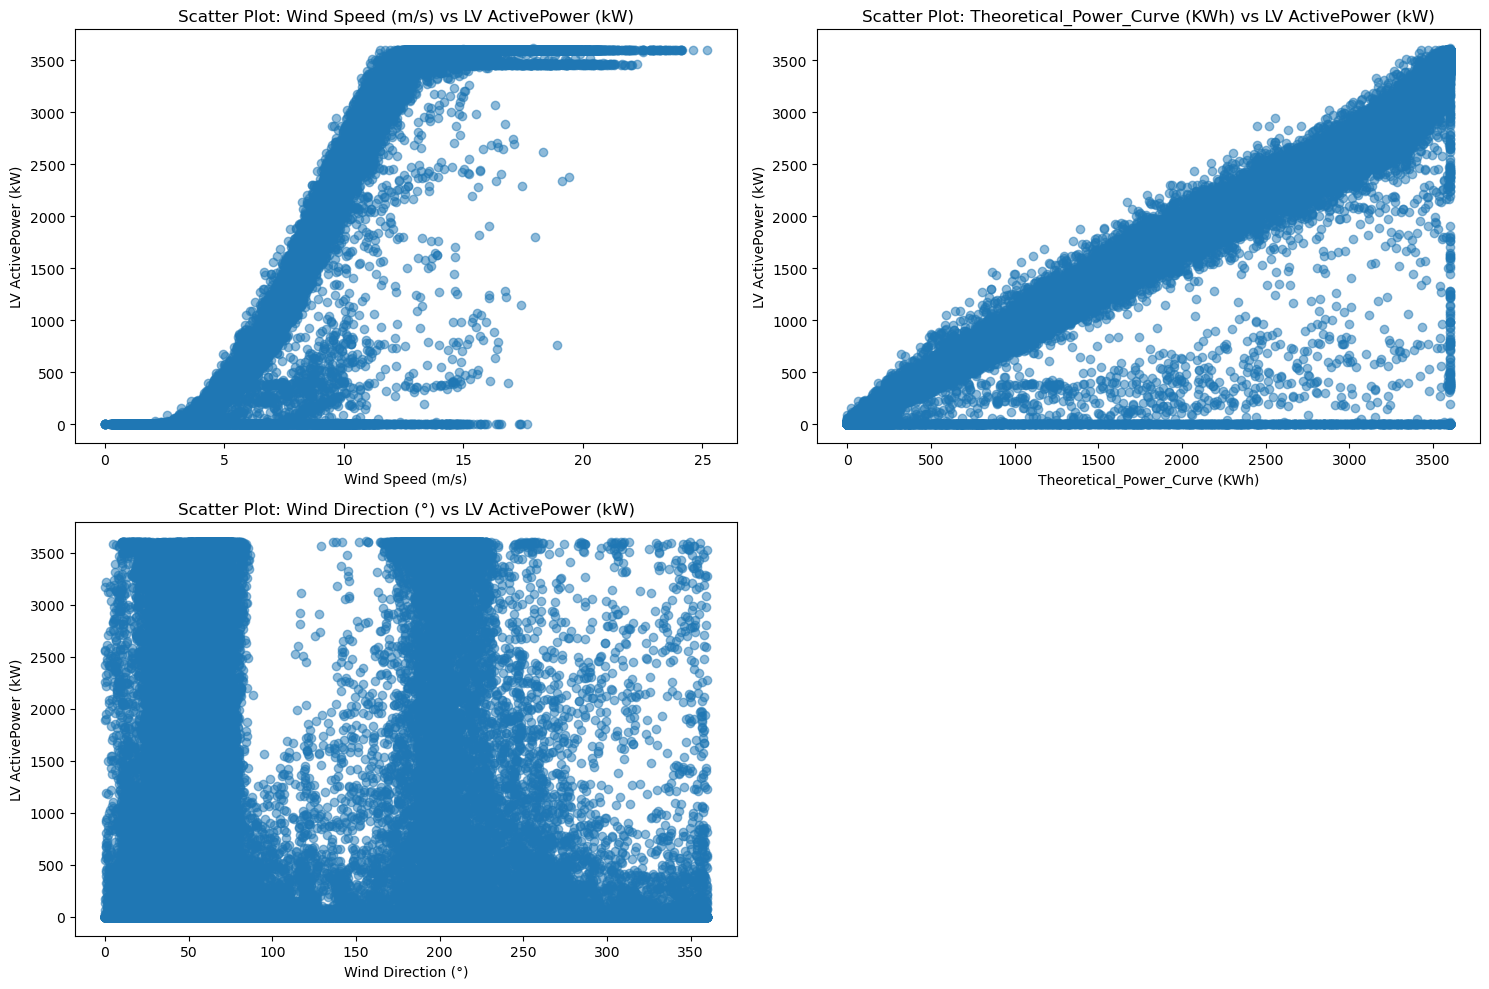

In [376]:
# using the scatter plot
target = 'LV ActivePower (kW)'
features = ['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']

#plots
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 2, i+1)  
    plt.scatter(data[feature], data[target], alpha=0.5)
    plt.title(f'Scatter Plot: {feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)

plt.tight_layout()
plt.show()

 ## Section 3: Data Visualization

In [377]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


C:\Users\aalma\AppData\Local\Temp\ipykernel_30088\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data.iloc[:,i+1], shade=True)
C:\Users\aalma\AppData\Local\Temp\ipykernel_30088\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data.iloc[:,i+1], shade=True)
C:\Users\aalma\AppData\Local\Temp\ipykernel_30088\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data.iloc[:,i+1], shade=True)
C:\Users\aalma\AppData\Local\Temp\ipykernel_30088\3440136882.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; pl

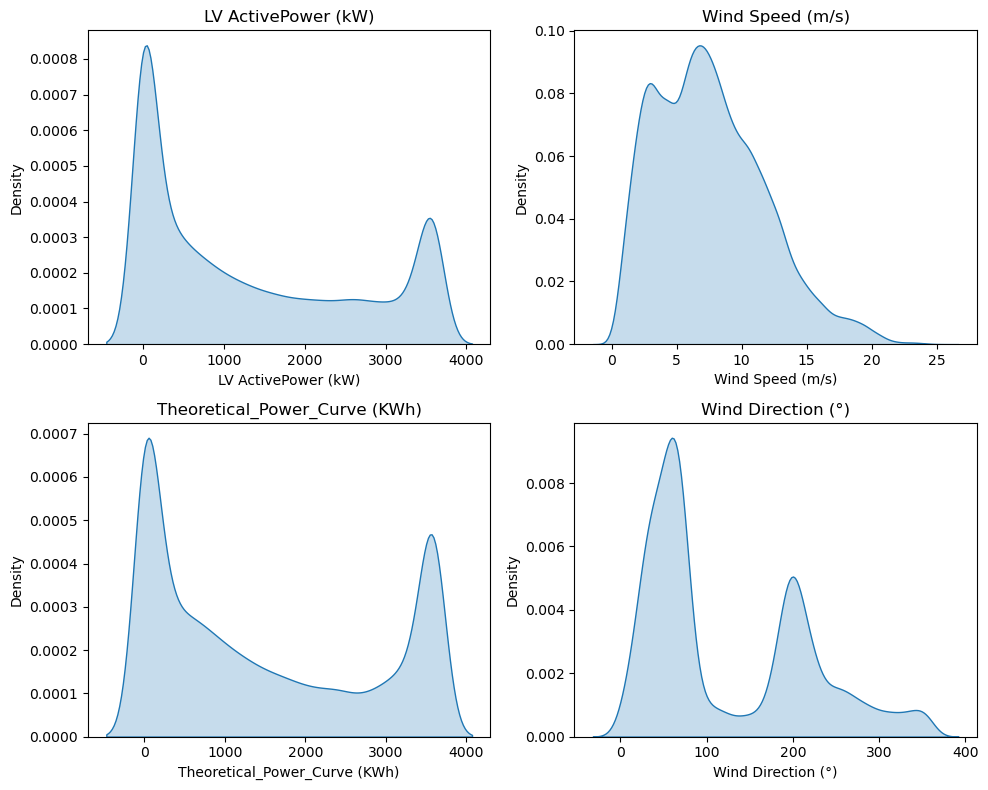

In [378]:
# plot the kde of the data
plt.figure(figsize=(10, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(data.iloc[:,i+1], shade=True)
    plt.title(data.columns[i+1])
plt.tight_layout()
plt.show()

In [379]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


## Section 4: Preprocessing Data (Selecting the target, features, scaling, splitting)

In [380]:
x = [1]  # Convert x to a list
data1 = data.loc[data['Month'].isin(x)]  # selecting the data for the month x
data1 = data1.reset_index(drop=True)  # resetting the index
data1 = data1.dropna()  # dropping the missing values

data_new = data1['LV ActivePower (kW)']  # selecting the active power
data_new = pd.DataFrame(data_new)  # converting to dataframe

data_new.head()

,LV ActivePower (kW)
0,57.407021
1,27.440510
2,0.364866
3,0.000000
4,0.000000


In [381]:
# find the total number of rows
total_rows = data_new.count()
total_rows

LV ActivePower (kW)    4447
dtype: int64

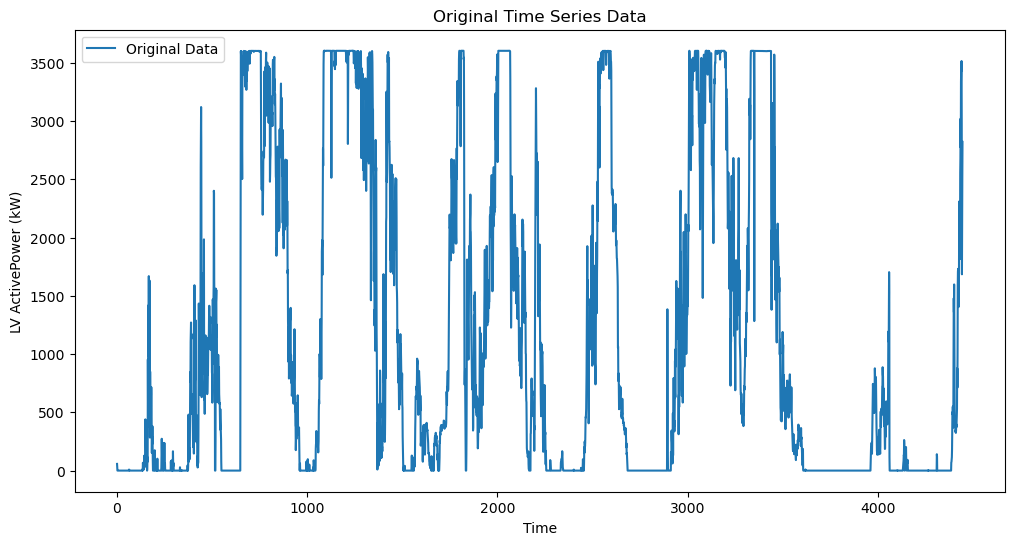

In [382]:
# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(data_new.index, data_new.values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()

((3557, 1), (890, 1))

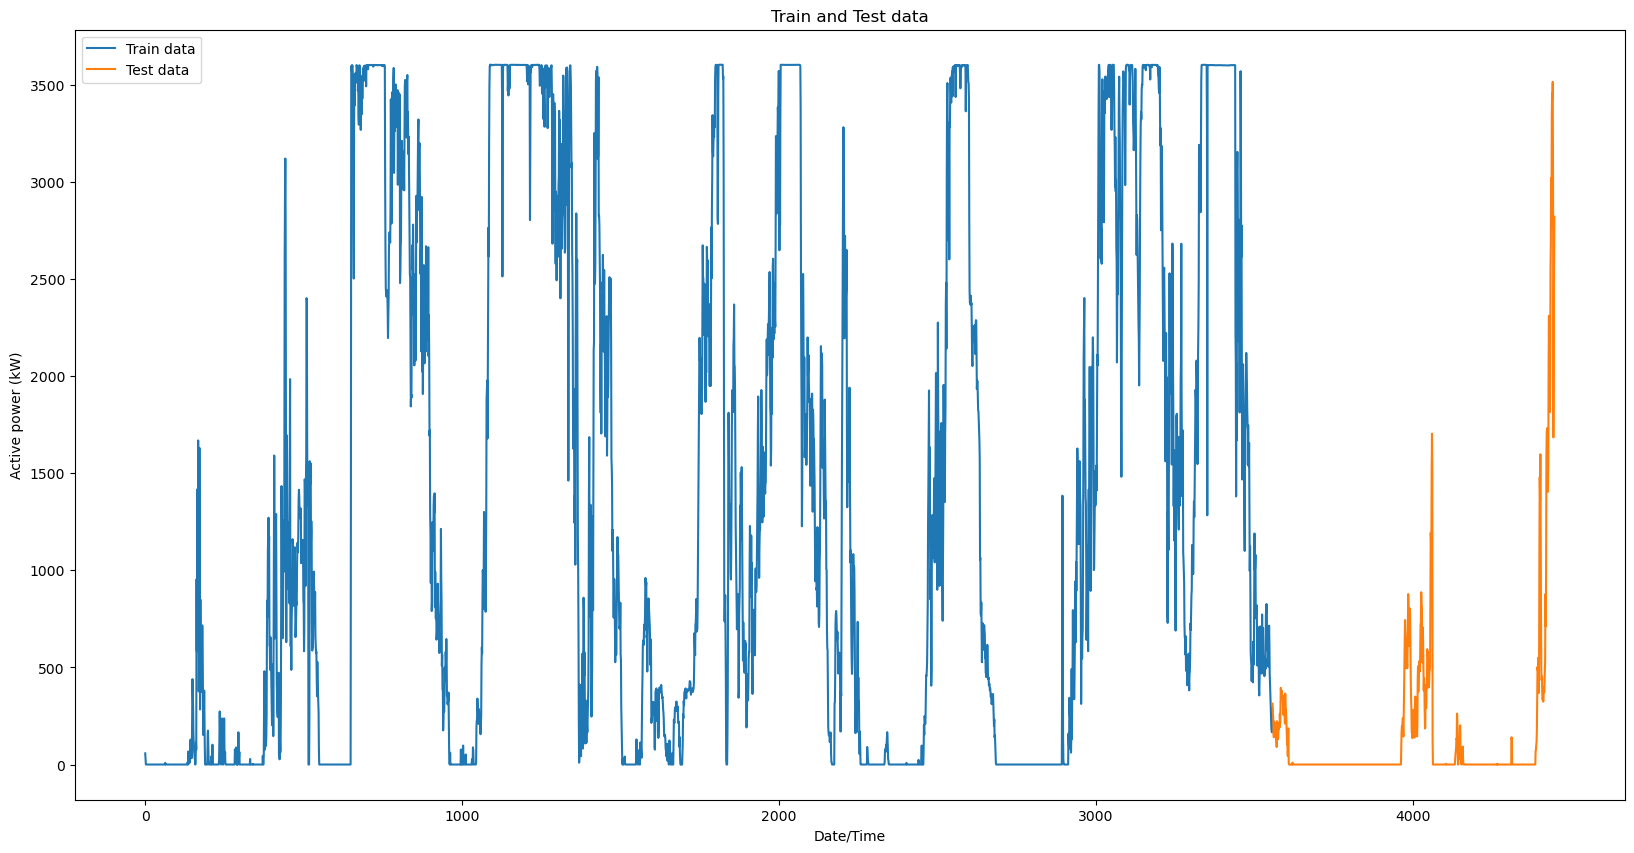

In [383]:
# split the data into training and testing data
train_size = int(len(data_new) * 0.80)
train_data, test_data = data_new.iloc[:train_size], data_new.iloc[train_size:]

#plot the train and test data
plt.figure(figsize=(20, 10))
plt.plot(train_data.index, train_data['LV ActivePower (kW)'], label='Train data')
plt.plot(test_data.index, test_data['LV ActivePower (kW)'], label='Test data')
plt.title('Train and Test data')
plt.xlabel('Date/Time')
plt.ylabel('Active power (kW)')
plt.legend()

# shape of the train and test data
train_data.shape, test_data.shape


In [384]:
def create_xy(data, input_length, output_length):
    """
    Generates input (x) and output (y) pairs from time series data based on the specified input and output lengths.

    Parameters:
    - data (np.ndarray or list): The time series data as a numpy array or list.
    - input_length (int): The number of time steps for the input sequence.
    - output_length (int): The number of time steps for the output sequence.

    Returns:
    - x (np.ndarray): The array of input sequences with shape (num_samples, input_length).
    - y (np.ndarray): The array of output sequences with shape (num_samples, output_length).
    """
    x, y = [], []
    total_length = len(data)

    # Iterate over the dataset to create input-output pairs
    for i in range(total_length - input_length - output_length + 1):
        x.append(data[i:i + input_length])
        y.append(data[i + input_length:i + input_length + output_length])
    
    return np.array(x), np.array(y)

In [385]:
# Convert the train and test data to NumPy arrays
train_data_np = train_data.values
test_data_np = test_data.values

# set the input and output lengths
input_length = 9
output_length = 1
# Get the X_train and y_train from the training data
X_train, y_train = create_xy(train_data_np, input_length, output_length)

# Get the X_test and y_test from the test data
X_test, y_test = create_xy(test_data_np, input_length, output_length)

# Print the shape of the training data and testing data
print(f"X_train shape: {X_train.shape}| y_train shape: {y_train.shape}") # (num_samples, input_length) | (num_samples, output_length)
print(f"X_test shape: {X_test.shape}| y_test shape: {y_test.shape}") # (num_samples, input_length) | (num_samples, output_length)

X_train shape: (3551, 6, 1)| y_train shape: (3551, 1, 1)
X_test shape: (884, 6, 1)| y_test shape: (884, 1, 1)


In [386]:
# reshape the X_train and X_test by removing the last dimension
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1])

# reshape the y_train and y_test by removing the last two dimensions
y_train = y_train.reshape(y_train.shape[0])
y_test = y_test.reshape(y_test.shape[0])

# Print the shape of the training data and testing data
print(f"X_train shape: {X_train.shape}| y_train shape: {y_train.shape}") # (num_samples, input_length) | (num_samples, output_length)
print(f"X_test shape: {X_test.shape}| y_test shape: {y_test.shape}") # (num_samples, input_length) | (num_samples, output_length)

X_train shape: (3551, 6)| y_train shape: (3551,)
X_test shape: (884, 6)| y_test shape: (884,)


In [387]:
# check the first element of the X_train and y_train
X_train[0], y_train[0]

(array([57.40702057, 27.4405098 ,  0.3648665 ,  0.        ,  0.        ,
         0.        ]),
 0.0)

In [388]:
# check the second element of the X_train and y_train
X_train[1], y_train[1]

(array([27.4405098,  0.3648665,  0.       ,  0.       ,  0.       ,
         0.       ]),
 0.0)

In [389]:
y_train[0:11]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [390]:
y_test[0:11]

array([153.18130493, 207.85780334, 168.76829529, 211.15789795,
       186.82699585, 195.07069397, 118.66220093,  90.35288239,
       222.8598938 , 177.21839905, 177.07749939])

In [391]:
# Different scaler for input and output
scaler_x= MinMaxScaler(feature_range = (0,1))
scaler_y = MinMaxScaler(feature_range = (0,1))

# Fit the scaler using available training data
input_scaler = scaler_x.fit(X_train)
output_scaler = scaler_y.fit(y_train.reshape(-1, 1))

# Apply the scaler to training data
X_train_scaled = input_scaler.transform(X_train) 
y_train_scaled = output_scaler.transform(y_train.reshape(-1, 1))  

# Transform the test data
X_test_scaled = input_scaler.transform(X_test)
y_test_scaled = output_scaler.transform(y_test.reshape(-1, 1))

In [392]:
# Add a dimension to X_train_scaled and X_test_scaled
X_train = X_train_scaled[..., np.newaxis]
X_test = X_test_scaled[..., np.newaxis]

# Add a dimension to y_train_scaled and y_test_scaled
y_train = y_train_scaled.reshape(-1, 1)
y_test = y_test_scaled.reshape(-1, 1)


# Print the shape of the scaled training data and testing data
print(f"X_train_scaled shape: {X_train.shape}| y_train_scaled shape: {y_train.shape}") # (num_samples, input_length, 1) | (num_samples, output_length, 1)
print(f"X_test_scaled shape: {X_test.shape}| y_test_scaled shape: {y_test.shape}") # (num_samples, input_length, 1) | (num_samples, output_length, 1)

X_train_scaled shape: (3551, 6, 1)| y_train_scaled shape: (3551, 1)
X_test_scaled shape: (884, 6, 1)| y_test_scaled shape: (884, 1)


### Step 3: Building the models and Training them

## Section 1: building the model

In [ ]:
def create_model(units, layer_type):
    model = Sequential()
    
    model.add(layer_type(units=units, dropout=0.05, return_sequences=True,
                         input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    
    model.add(layer_type(units=units, dropout=0.2))
    
    model.add(Dense(units=1))
    
    optimizer = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer)
    return model

# models
model_gru = create_model(128, GRU)


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [394]:
# Fit models
def fit_model(model):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 7)

    
    history = model.fit(X_train, y_train, epochs = 30, validation_split = 0.2,
                    batch_size = 64, shuffle = False, callbacks = [early_stop])
    return history

## Section 2: Training the models

In [395]:
history_gru = fit_model(model_gru)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1109 - val_loss: 0.0300
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0401 - val_loss: 0.0166
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0223 - val_loss: 0.0148
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209 - val_loss: 0.0156
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0225 - val_loss: 0.0154
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0195 - val_loss: 0.0148
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0213 - val_loss: 0.0142
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0192 - val_loss: 0.0125
Epoch 9/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0210 - val_loss: 0.0136
Epoch 10/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0178 - val_loss: 0.0122
Epoch 11/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209 - val_loss: 0.0119
Epoch 12/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0199 - val_l

## Section 3: Viuslization of train and validation loss

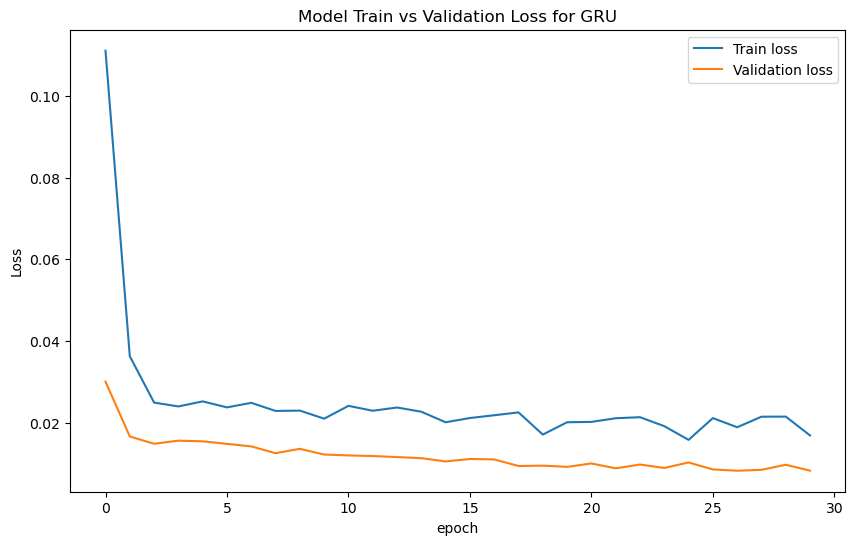

In [396]:
def plot_loss (history, model_name):
    plt.figure(figsize = (10, 6))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')
    plt.show()

# Plot loss
plot_loss (history_gru, 'GRU')

### Step 4: Evaluation and Visulization

In [397]:
# Note that we have to use scaler_y
y_test = scaler_y.inverse_transform(y_test)
y_train = scaler_y.inverse_transform(y_train)

In [398]:
def prediction(model):
    prediction = model.predict(X_test)
    prediction = scaler_y.inverse_transform(prediction)
    return prediction

prediction_gru = prediction(model_gru)


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step 


In [399]:
# Create a DataFrame for the actual and predicted values
comparison_df = pd.DataFrame({
    'Actual': y_test.flatten(),    
    'GRU_Prediction': prediction_gru.flatten(), 
})

# Display the first 10 elements of the DataFrame
comparison_df.head(10)

,Actual,GRU_Prediction
0,153.181305,310.124054
1,207.857803,297.406586
2,168.768295,310.384613
3,211.157898,303.614288
4,186.826996,315.649719
5,195.070694,313.840881
6,118.662201,314.701416
7,90.352882,282.054993
8,222.859894,248.409058
9,177.218399,288.358978


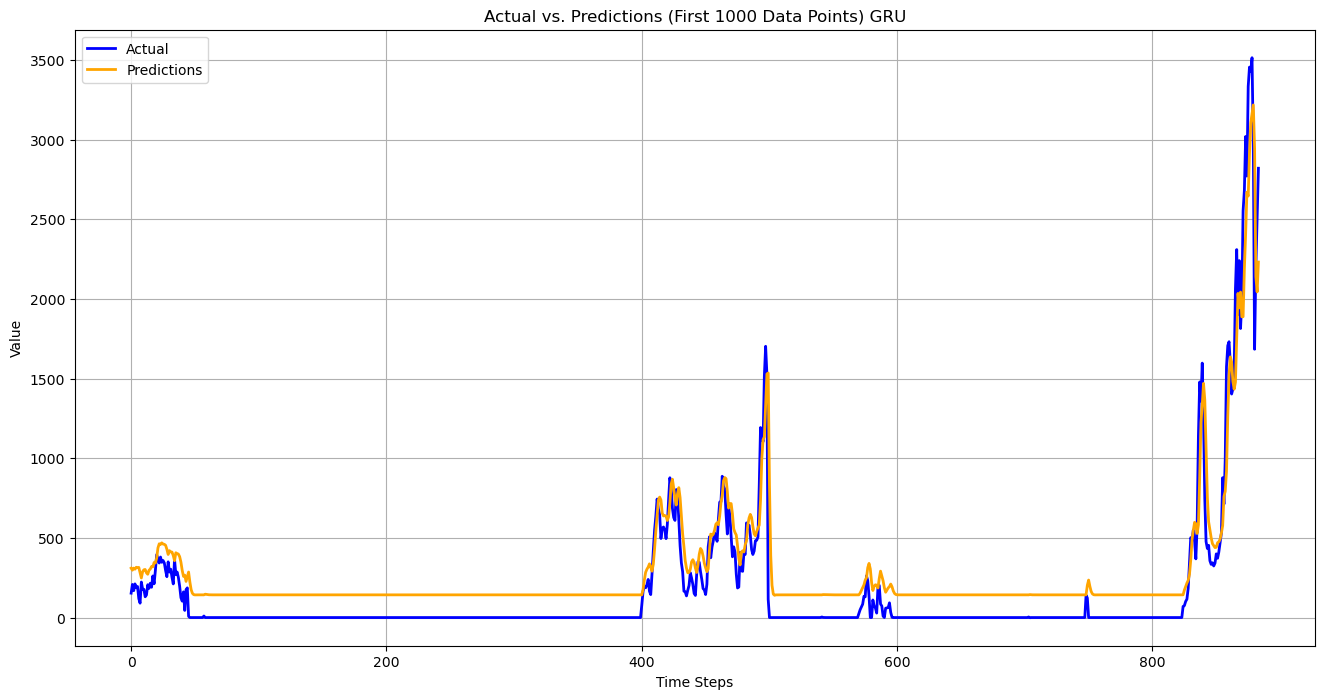

In [400]:
def plot_predictions_comparison(actual, prediction, model_name, num_points=1000):
    plt.figure(figsize=(16, 8))  # Increased figure size for better visibility

    # Select the first 1000 elements for plotting
    actual_plot = y_test[:num_points]
    prediction_plot = prediction[:num_points]

    # Create the plot
    plt.plot(actual_plot, label='Actual', color='blue', linewidth=2)
    plt.plot(prediction_plot, label='Predictions', color='orange', linewidth=2)

    plt.title('Actual vs. Predictions (First 1000 Data Points) ' + model_name)
    plt.xlabel('Time Steps')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()



# Plot the first 1000 actual and predicted values
plot_predictions_comparison(y_test, prediction_gru, 'GRU')

In [401]:
# Define a function to calculate MAE and RMSE
def evaluate_prediction(predictions, actual, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mae = mean_absolute_error(actual, predictions)
    r2 = r2_score(actual, predictions)

    print(model_name + ':')
    print('Root Mean Square Error: {:.3f}'.format(rmse))
    print('Mean Absolute Error: {:.3f}'.format(mae))
    print('R^2 Score: {:.3f}'.format(r2))
    print('')

evaluate_prediction(prediction_gru, y_test, 'GRU')

GRU:
Root Mean Square Error: 177.409
Mean Absolute Error: 150.394
R^2 Score: 0.847

